In [1]:
!wget -O old_faithful.csv https://gist.githubusercontent.com/hogwild/c2704a1ae38c0a36983bc13121050dac/raw/oldFaithfulGeyserDataset.csv

--2026-10-04 14:48:59--  https://gist.githubusercontent.com/hogwild/c2704a1ae38c0a36983bc13121050dac/raw/oldFaithfulGeyserDataset.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3807 (3.7K) [text/plain]
Saving to: ‘old_faithful.csv’

old_faithful.csv    100%[===================>]   3.72K  --.-KB/s    in 0s      

2026-10-04 14:48:59 (38.9 MB/s) - ‘old_faithful.csv’ saved [3807/3807]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
data = pd.read_csv(
    "old_faithful.csv"
)

print(data.shape)

data.head()

(272, 3)


,index,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


In [4]:
print(data.isnull().sum())

index        0
eruptions    0
waiting      0
dtype: int64


In [5]:
X = data[
    ['eruptions', 'waiting']
]

X.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


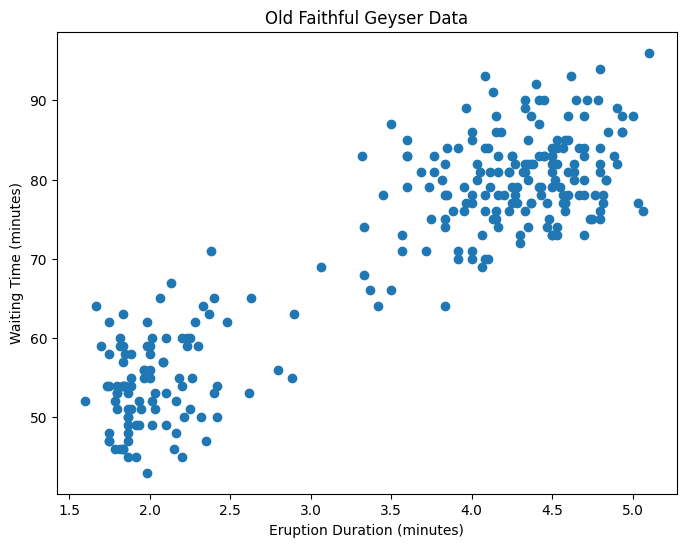

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['eruptions'],
    X['waiting']
)

plt.xlabel(
    "Eruption Duration (minutes)"
)

plt.ylabel(
    "Waiting Time (minutes)"
)

plt.title(
    "Old Faithful Geyser Data"
)

plt.show()

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

In [8]:
wcss = []

for i in range(1, 11):

    model = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(
        model.inertia_
    )

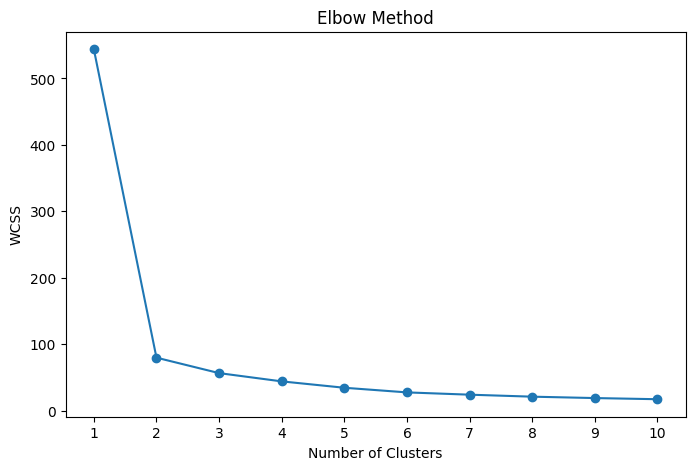

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "WCSS"
)

plt.title(
    "Elbow Method"
)

plt.xticks(
    range(1, 11)
)

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

print(clusters)

[0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0]


In [11]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print(
    "Cluster Centers:"
)

print(
    centers
)

Cluster Centers:
[[ 4.29632759 80.08045977]
 [ 2.05220408 54.59183673]]


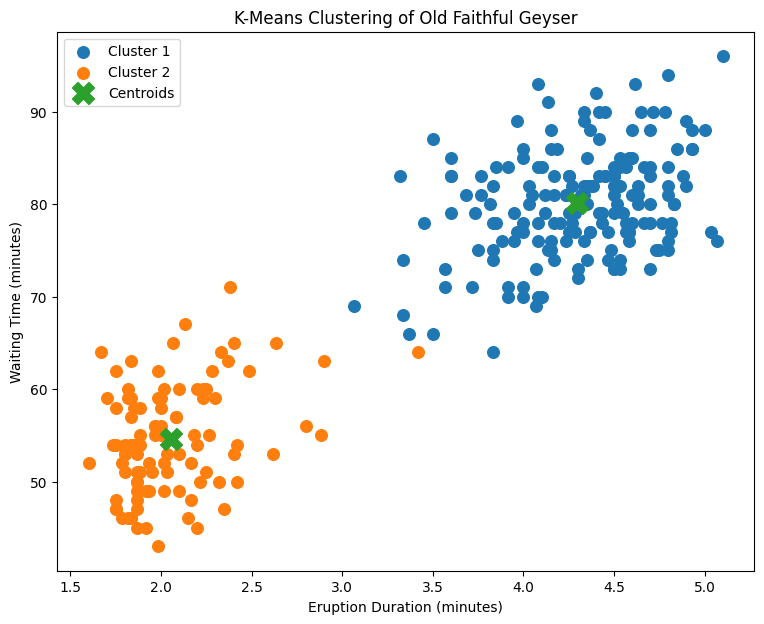

In [12]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X.iloc[clusters == 0, 0],
    X.iloc[clusters == 0, 1],
    s=70,
    label='Cluster 1'
)

plt.scatter(
    X.iloc[clusters == 1, 0],
    X.iloc[clusters == 1, 1],
    s=70,
    label='Cluster 2'
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=250,
    marker='X',
    label='Centroids'
)

plt.xlabel(
    "Eruption Duration (minutes)"
)

plt.ylabel(
    "Waiting Time (minutes)"
)

plt.title(
    "K-Means Clustering of Old Faithful Geyser"
)

plt.legend()

plt.show()

In [13]:
score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "Silhouette Score:",
    score
)

Silhouette Score: 0.7451774401188772
